In [1]:
from langchain.chat_models import init_chat_model
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

In [2]:
# file is in app/.env
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages] # function of Annotated[T, x] is to create a type T with the additional metadata x attached to it.

In [4]:
@tool
def get_stock_price(symbol: str) -> str:
    '''Return the current price of a stock given the stock symbol
    :param symbol: stock symbol
    :return: current price of the stock
    '''
    return {
        "MSFT": 200.3,
        "AAPL": 100.4,
        "AMZN": 150.0,
        "RIL": 87.6
    }.get(symbol,0.0)
tools= [get_stock_price]

llm = init_chat_model("gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

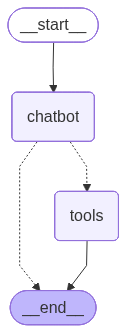

In [5]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}
builder = StateGraph(State)

builder.add_node(chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)

graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
state= graph.invoke({"messages": [{"role": "user", "content": "What is the current stock price of AAPL?"}]})
print(state["messages"][-1].content)

100.4


In [7]:
state = graph.invoke({"messages": [{"role": "user", "content": "Who invented gravity print person name only"}]})
print(state["messages"][-1].content)

Isaac Newton


In [8]:
msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]})
print(state["messages"][-1].content)

200.3


In [9]:
#  still now our langgraph agent is only able to call one tool at a time. So in the above example, 
# it will call the tool to get the price of AMZN and then call the tool to get the price of MSFT. 
# It will not be able to call both tools in parallel.
# This is because we have defined our graph in a way that it can only call one tool at a time.

#  so basically it is not a agentic behavior, 
#  to make this behave like agent it must call the tools in a parallel or again to get and next to llm like cycle unit

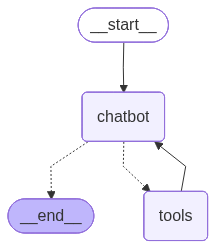

In [10]:
#  recunstructing the graph
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}
builder = StateGraph(State)

builder.add_node(chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot") # this is a cycle unit

graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

now we can see here that this graph will work like agent
see here it takes the tow stoke prices one by one (like first one and go again to chatbot and get one more)
nect by using that two calculate the value

In [11]:
msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]})
print(state["messages"][-1].content)

The current prices for the stocks are as follows:
- Amazon (AMZN): $150.00
- Microsoft (MSFT): $200.30

Now, let's calculate the total cost for buying 20 AMZN stocks and 15 MSFT stocks.

1. **Cost of AMZN**: 20 stocks × $150.00 = $3,000.00
2. **Cost of MSFT**: 15 stocks × $200.30 = $3,004.50

**Total Cost**: $3,000.00 + $3,004.50 = $6,004.50

The total cost for buying 20 AMZN stocks and 15 MSFT stocks will be **$6,004.50**.


# add memory

In [12]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

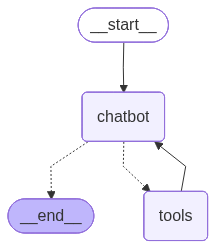

In [13]:
#  recunstructing the graph
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}
builder = StateGraph(State)

builder.add_node(chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot") # this is a cycle unit

graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
config1= {"configurable": {"thread_id": "1"}}
# here we can mentain 2 threads of conversation with the same graph, by passing different thread_id in the config.
#  So that the memory will be maintained separately for each thread.
msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config1)
print(state["messages"][-1].content)

The current prices are as follows:
- Amazon (AMZN): $150.00
- Microsoft (MSFT): $200.30

Now, calculating the total cost for 20 AMZN stocks and 15 MSFT stocks:

- Total cost for AMZN: \( 20 \times 150.00 = 3000.00 \)
- Total cost for MSFT: \( 15 \times 200.30 = 3004.50 \)

Combining both costs:
- Total cost = \( 3000.00 + 3004.50 = 6004.50 \)

Therefore, the total cost will be **$6004.50**.


In [15]:
config2 = { 'configurable': { 'thread_id': '2'} } # we can start a new conversation thread with the same graph, and it will maintain a separate memory for this thread2 .

msg = "Tell me the current price of 5 AAPL stocks."

state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config2)
print(state["messages"][-1].content)

The current price of one AAPL stock is $100.40. Therefore, the price for 5 AAPL stocks would be $502.00.


In [16]:
msg = "Using the current price tell me the total price of 10 RIL stocks and add it to previous total cost"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config1)
print(state["messages"][-1].content)

The current price for Reliance Industries (RIL) is $87.60. 

Now, calculating the total cost for 10 RIL stocks:
- Total cost for RIL: \( 10 \times 87.60 = 876.00 \)

Adding this to the previous total cost of $6004.50:
- New total cost = \( 6004.50 + 876.00 = 6880.50 \)

The updated total cost will be **$6880.50**.


In [17]:
msg = "Tell me the current price of 5 MSFT stocks and add it to previous total"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config2)
print(state["messages"][-1].content)


The current price of one MSFT stock is $200.30. Therefore, the price for 5 MSFT stocks would be $1,001.50.

Adding that to the previous total of $502.00 for the AAPL stocks, the new total is $1,503.50.


# now we will add langsmith for tracing the work

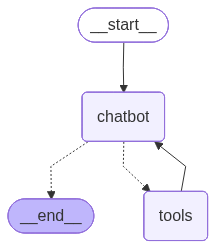

In [18]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node(chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")
graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
from langsmith import traceable

@traceable
def call_graph(query: str):
    state = graph.invoke({"messages": [{"role": "user", "content": query}]})
    return state["messages"][-1].content

call_graph("I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?")

'The current price of AMZN (Amazon) is $150.00, and the current price of MSFT (Microsoft) is $200.30.\n\nTo calculate the total cost for purchasing 20 AMZN stocks and 15 MSFT stocks:\n\n1. Total cost for AMZN = 20 stocks * $150.00 = $3,000.00\n2. Total cost for MSFT = 15 stocks * $200.30 = $3,004.50\n\nNow, adding both totals together:\n\nTotal cost = $3,000.00 + $3,004.50 = **$6,004.50**\n\nSo, the total cost for purchasing 20 AMZN stocks and 15 MSFT stocks will be **$6,004.50**.'